<a href="https://colab.research.google.com/github/esthy13/cil-intrusion-detection/blob/main/notebooks/0_data_cleaning_UNSWNB15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Data Cleaning for UNSW-NB15 dataset

In [1]:
from google.colab import userdata
token = userdata.get('GIT_TOKEN')
username = userdata.get('USERNAME')
email = userdata.get('EMAIL')
!git config --global user.email {email}
!git config --global user.name {username}
repo = "cil-intrusion-detection"

In [2]:
!git clone https://{token}@github.com/{username}/{repo}
%cd {repo}
!git pull origin main

Cloning into 'cil-intrusion-detection'...
remote: Enumerating objects: 1700, done.
remote: Counting objects: 100% (423/423), done.
remote: Compressing objects: 100% (208/208), done.
remote: Total 1700 (delta 268), reused 342 (delta 215), pack-reused 1277 (from 1)
Receiving objects: 100% (1700/1700), 209.71 MiB | 24.71 MiB/s, done.
Resolving deltas: 100% (840/840), done.
/content/cil-intrusion-detection
From https://github.com/esthy13/cil-intrusion-detection
 * branch            main       -> FETCH_HEAD
Already up to date.


## 1. Importing the dataset

In [3]:
import pandas as pd
df = pd.read_csv('data/raw/UNSW_NB15_training-set.csv')
df_test = pd.read_csv('data/raw/UNSW_NB15_testing-set.csv')

In [4]:
print("Train shape:", df.shape)
print("Test shape:", df_test.shape)

display(df.head())

Train shape: (175341, 45)
Test shape: (82332, 45)


,id,dur,proto,service,state,spkts,dpkts,sbytes,dbytes,rate,...,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,attack_cat,label
0,1,0.121478,tcp,-,FIN,6,4,258,172,74.087490,...,1,1,0,0,0,1,1,0,Normal,0
1,2,0.649902,tcp,-,FIN,14,38,734,42014,78.473372,...,1,2,0,0,0,1,6,0,Normal,0
2,3,1.623129,tcp,-,FIN,8,16,364,13186,14.170161,...,1,3,0,0,0,2,6,0,Normal,0
3,4,1.681642,tcp,ftp,FIN,12,12,628,770,13.677108,...,1,3,1,1,0,2,1,0,Normal,0
4,5,0.449454,tcp,-,FIN,10,6,534,268,33.373826,...,1,40,0,0,0,2,39,0,Normal,0


id column should be dropped as it's redundant

In [5]:
df.describe()

,id,dur,spkts,dpkts,sbytes,dbytes,rate,sttl,dttl,sload,...,ct_src_dport_ltm,ct_dst_sport_ltm,ct_dst_src_ltm,is_ftp_login,ct_ftp_cmd,ct_flw_http_mthd,ct_src_ltm,ct_srv_dst,is_sm_ips_ports,label
count,175341.000000,175341.000000,175341.000000,175341.000000,1.753410e+05,1.753410e+05,1.753410e+05,175341.000000,175341.000000,1.753410e+05,...,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000,175341.000000
mean,87671.000000,1.359389,20.298664,18.969591,8.844844e+03,1.492892e+04,9.540619e+04,179.546997,79.609567,7.345403e+07,...,5.383538,4.206255,8.729881,0.014948,0.014948,0.133066,6.955789,9.100758,0.015752,0.680622
std,50616.731112,6.480249,136.887597,110.258271,1.747656e+05,1.436542e+05,1.654010e+05,102.940011,110.506863,1.883574e+08,...,8.047104,5.783585,10.956186,0.126048,0.126048,0.701208,8.321493,10.756952,0.124516,0.466237
min,1.000000,0.000000,1.000000,0.000000,2.800000e+01,0.000000e+00,0.000000e+00,0.000000,0.000000,0.000000e+00,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000
25%,43836.000000,0.000008,2.000000,0.000000,1.140000e+02,0.000000e+00,3.278614e+01,62.000000,0.000000,1.305334e+04,...,1.000000,1.000000,1.000000,0.000000,0.000000,0.000000,2.000000,2.000000,0.000000,0.000000
50%,87671.000000,0.001582,2.000000,2.000000,4.300000e+02,1.640000e+02,3.225807e+03,254.000000,29.000000,8.796748e+05,...,1.000000,1.000000,3.000000,0.000000,0.000000,0.000000,3.000000,4.000000,0.000000,1.000000
75%,131506.000000,0.668069,12.000000,10.000000,1.418000e+03,1.102000e+03,1.250000e+05,254.000000,252.000000,8.888889e+07,...,5.000000,3.000000,12.000000,0.000000,0.000000,0.000000,9.000000,12.000000,0.000000,1.000000
max,175341.000000,59.999989,9616.000000,10974.000000,1.296523e+07,1.465555e+07,1.000000e+06,255.000000,254.000000,5.988000e+09,...,51.000000,46.000000,65.000000,4.000000,4.000000,30.000000,60.000000,62.000000,1.000000,1.000000


In [6]:
# Remove duplicates and drop unnecessary columns
df = df.drop_duplicates()
df_test = df_test.drop_duplicates()
print("Train shape:", df.shape)
print("Test shape:", df_test.shape)

Train shape: (175341, 45)
Test shape: (82332, 45)


There are no duplicates rows in both datasets

In [7]:
print(df['label'].value_counts())
print(df['attack_cat'].value_counts())

label
1    119341
0     56000
Name: count, dtype: int64
attack_cat
Normal            56000
Generic           40000
Exploits          33393
Fuzzers           18184
DoS               12264
Reconnaissance    10491
Analysis           2000
Backdoor           1746
Shellcode          1133
Worms               130
Name: count, dtype: int64


We can see that `label` column contains only two labels, 0 and 1 for binary classification of attack with $0 = benign$ and $1 = attack$. The `attack_cat`, instead contains labels for multi-class classification referring to 9 different type of attacks. However, `Worms` attack were removed due to the ex-
tremely small number of samples (130 instances), which is insufficient for stable incremental training.

In [8]:
df = df.drop(columns=['id', 'label', 'is_sm_ips_ports'], errors='ignore')
df_test = df_test.drop(columns=['id', 'label', 'is_sm_ips_ports'], errors='ignore')

In [9]:
# Filter out rows with 'Worms' attack category
df = df[df['attack_cat'] != 'Worms']
df_test = df_test[df_test['attack_cat'] != 'Worms']

In [10]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
numerical_cols   = df_test.select_dtypes(include=['int64', 'float64']).columns.tolist()

print("Categorical columns:", categorical_cols)

Categorical columns: ['proto', 'service', 'state', 'attack_cat']


There are other three categorical columns in the dataset: `proto`, `service` and `state`.

In [11]:
print(df['service'].value_counts())
print(df['state'].value_counts())
print(df['proto'].value_counts())

service
-           94152
dns         47294
http        18610
smtp         5058
ftp-data     3995
ftp          3428
ssh          1302
pop3         1105
dhcp           94
snmp           80
ssl            56
irc            25
radius         12
Name: count, dtype: int64
state
INT    82260
FIN    77712
CON    13150
REQ     1991
RST       83
ECO       12
PAR        1
URN        1
no         1
Name: count, dtype: int64
proto
tcp       79831
udp       63268
unas      12084
arp        2859
ospf       2595
          ...  
argus        98
netblt       98
igmp         18
icmp         15
rtp           1
Name: count, Length: 133, dtype: int64


The columns `service`, `state`, and `proto` contain categorical string values representing network services, connection states, and communication protocols. These values are non-ordinal, meaning there's no inherent ranking or order, making one-hot encoding the ideal method to convert them into a numerical format.This method transforms each unique category into a binary vector, creating separate columns for each category.

In [12]:
from sklearn.preprocessing import OneHotEncoder

# Categorical variables
cat_vars = ['proto', 'service', 'state']

# Initialize OneHotEncoder
encoder = OneHotEncoder(
    sparse_output=False,      # Returns dense array (better for pandas/NN)
    handle_unknown='ignore'   # Avoid crash if a new category appears
)

# Apply One-Hot Encoding
encoded_array = encoder.fit_transform(df[cat_vars])
encoded_array_test = encoder.transform(df_test[cat_vars])

# Get encoded column names
encoded_cols = encoder.get_feature_names_out(cat_vars)

# Create DataFrame for encoded values
df_encoded = pd.DataFrame(encoded_array, columns=encoded_cols, index=df.index)
df_encoded_test = pd.DataFrame(encoded_array_test, columns=encoded_cols, index=df_test.index)

# Concatenate encoded columns and drop original categorical columns
df = pd.concat([df.drop(columns=cat_vars), df_encoded], axis=1)
df_test = pd.concat([df_test.drop(columns=cat_vars), df_encoded_test], axis=1)

In [ ]:
# shape after one-hot-encoding
print("Train shape:", df.shape)
print("Test shape:", df_test.shape)

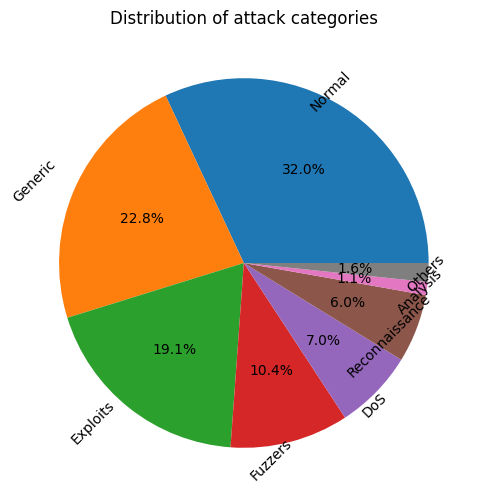

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

counts = df["attack_cat"].value_counts()
threshold = 0.01  # 1%

# Convert to proportions
proportions = counts / counts.sum()

# Group small categories
large = counts[proportions >= threshold]
small = counts[proportions < threshold]

if not small.empty:
    large["Others"] = small.sum()

plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    large,
    labels=large.index,
    autopct='%1.1f%%',
)

for text in texts:
    text.set_rotation(45)
    text.set_ha('right')

plt.title('Distribution of attack categories')
plt.ylabel('')
plt.show()

In [21]:
import zipfile
from pathlib import Path
import tempfile
import shutil

# TODO: Check if the file is saved in the correct repository folder

def export_zip_with_root(df, df_test, zip_path):
    # Ensure the zip_path is within the "cil-intrusion-detection/data/processed" folder
    zip_path = Path(zip_path)
    processed_folder = Path("data/processed")  # Target folder

    # Make sure the target directory exists
    processed_folder.mkdir(parents=True, exist_ok=True)

    # Set the full zip_path within the correct "processed" folder
    zip_path = processed_folder / zip_path.name  # This saves the ZIP file in the processed folder

    zip_path.parent.mkdir(parents=True, exist_ok=True)  # Create directory if not exists

    temp_dir = Path(tempfile.mkdtemp())  # Temporary directory to hold CSVs

    # ROOT "2015" (required for loader structure)
    root = temp_dir / "2015"
    train_dir = root / "train"
    test_dir = root / "test"

    train_dir.mkdir(parents=True, exist_ok=True)  # Create train directory
    test_dir.mkdir(parents=True, exist_ok=True)   # Create test directory

    # Export TRAIN CSV per class
    for attack in sorted(df['attack_cat'].unique()):
        subset = df[df['attack_cat'] == attack]
        safe_name = str(attack).strip().replace(" ", "_").replace("/", "_")
        subset.to_csv(train_dir / f"{safe_name}.csv", index=False)

    # Export TEST CSV per class
    for attack in sorted(df_test['attack_cat'].unique()):
        subset = df_test[df_test['attack_cat'] == attack]
        safe_name = str(attack).strip().replace(" ", "_").replace("/", "_")
        subset.to_csv(test_dir / f"{safe_name}.csv", index=False)

    # Create ZIP preserving "2015/" as root
    with zipfile.ZipFile(zip_path, 'w', compression=zipfile.ZIP_DEFLATED) as z:
        for file in temp_dir.rglob("*.csv"):
            arcname = file.relative_to(temp_dir)  # Keep "2015/train/..." structure
            z.write(file, arcname)

    shutil.rmtree(temp_dir)  # Clean up temporary files
    print(f"ZIP compatible with loader created at: {zip_path}")

In [22]:
export_zip_with_root(df, df_test, "2015.zip")

ZIP compatible with loader created at: data/processed/2015.zip
